<a href="https://colab.research.google.com/github/aurabinda90-dev/CFD-in-Python/blob/main/Step_3_Convergence_and_the_CFL_Condition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 3: Convergence and the CFL Condition

In [ ]:
import numpy as np               #numpy is a library for array operations akin to MATLAB
from matplotlib import pyplot as plt    #matplotlib is 2D plotting library


def linearconv(nx):
    dx = 2/(nx - 1)
    nt = 20     #nt is the number of timesteps we want to calculate
    dt = 0.025  #dt is the amount of time each timestep covers (delta t)
    c = 1

    u = np.ones(nx)  #defining a numpy array which is nx elements long with every value equal to 1
    u[int(0.5/dx):int(1/dx+1)] = 2  #setting u = 2 between 0.5 and 1 as per our I.C.s

    un = np.ones(nx) #initializing our placeholder array, un, to hold the values we calculate for the n+1 timestep

    for n in range(nt): #iterate through time
        un = u.copy() #copy the existing values of u into un
        for i in range(1, nx):
            u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])

    plt.plot(np.linspace(0,2,nx),u)
    print("CFL number =", c*dt/dx)  # We will explain the meaning of CFL soon

CFL number = 0.5


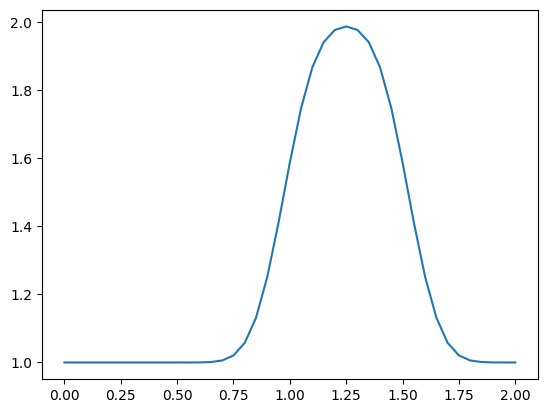

In [ ]:
linearconv(41)
#This is the same result as our Step 1 calculation, reproduced here for reference.

CFL number = 0.75


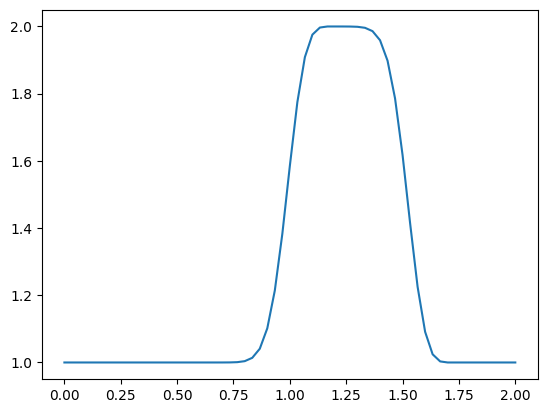

In [ ]:
linearconv(61)
#Here, there is still numerical diffusion present, but it is less severe.

CFL number = 1.0


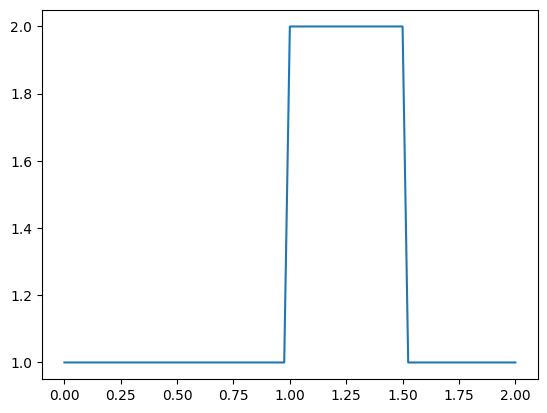

In [ ]:
linearconv(81)
#The wave is much more square than in the previous runs.

CFL number = 1.125


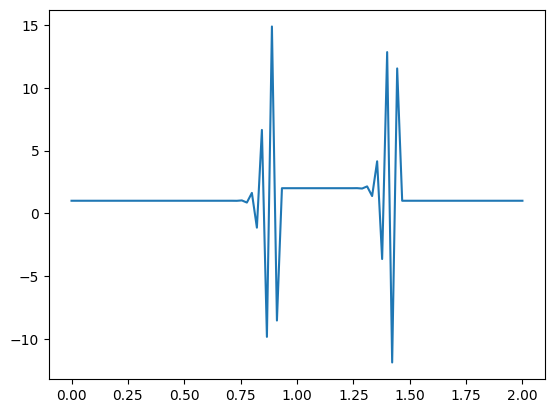

In [ ]:
linearconv(91)
#This doesn't look anything like our original hat function.
#The result blows up

In [ ]:
import numpy
from matplotlib import pyplot

def linearconv(nx):
    dx = 2 / (nx - 1)
    nt = 20    #nt is the number of timesteps we want to calculate
    c = 1
    CFL = 0.9   #the Courant number is always equal to 0.9

    dt = CFL * dx / c  # compute dt based on Courant number

    u = numpy.ones(nx)
    u[int(.5/dx):int(1 / dx + 1)] = 2

    un = numpy.ones(nx)

    for n in range(nt):  #iterate through time
        un = u.copy() ##copy the existing values of u into un
        for i in range(1, nx):
            u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])

    pyplot.plot(numpy.linspace(0, 2, nx), u)
    print("CFL number =", c*dt/dx)
    print("dt =", dt)

CFL number = 0.9
dt = 0.045000000000000005


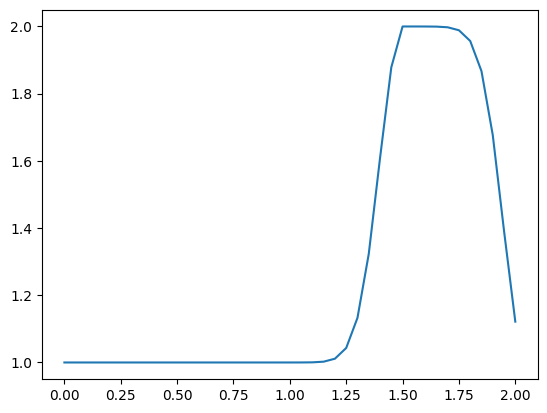

In [ ]:
linearconv(41)

CFL number = 0.9
dt = 0.03


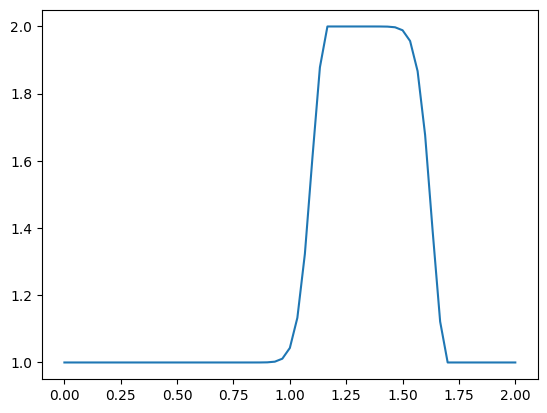

In [ ]:
linearconv(61)

CFL number = 0.9
dt = 0.022500000000000003


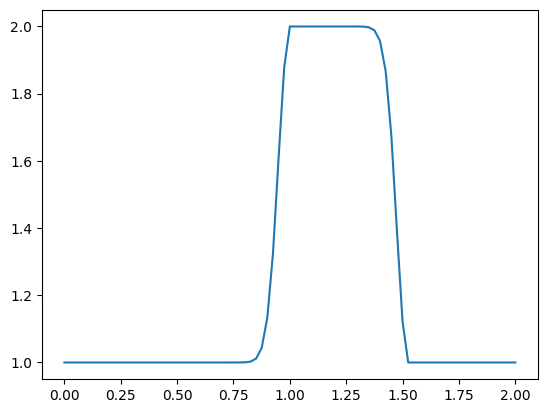

In [ ]:
linearconv(81)

CFL number = 0.9000000000000001
dt = 0.018000000000000002


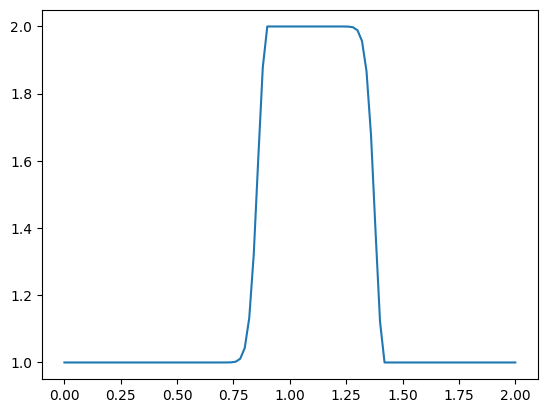

In [ ]:
linearconv(101)

CFL number = 0.9000000000000001
dt = 0.009000000000000001


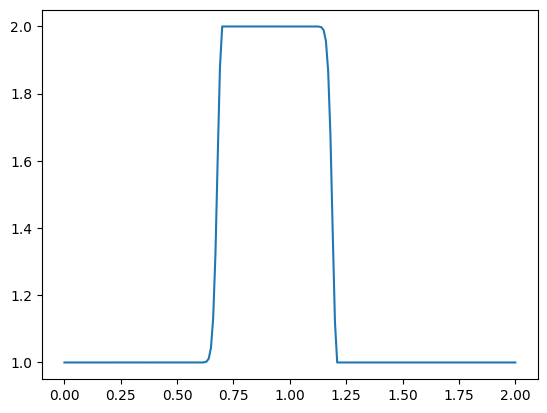

In [ ]:
linearconv(201)

In [ ]:
def linearconv_c(nx, c):
    dx = 2 / (nx - 1)
    nt = 20    #nt is the number of timesteps we want to calculate
    c = c

    dt = 0.018  # compute dt based on Courant number

    u = numpy.ones(nx)
    u[int(.5/dx):int(1 / dx + 1)] = 2

    un = numpy.ones(nx)

    for n in range(nt):  #iterate through time
        un = u.copy() ##copy the existing values of u into un
        for i in range(1, nx):
            u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])

    pyplot.plot(numpy.linspace(0, 2, nx), u)
    print("CFL number =", c*dt/dx)
    print("dt =", dt)

CFL number = -0.8999999999999999
dt = 0.018


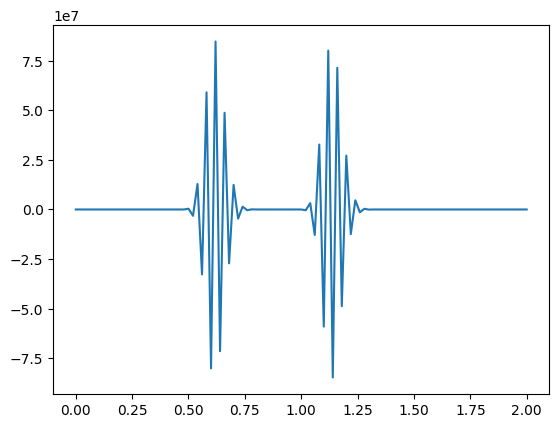

In [ ]:
linearconv_c(101,-1)

In [ ]:
def upwind_c(nx, c):
    dx = 2 / (nx - 1)
    nt = 20    #nt is the number of timesteps we want to calculate
    c = c

    dt = 0.018  # compute dt based on Courant number

    u = numpy.ones(nx)
    u[int(.5/dx):int(1 / dx + 1)] = 2

    un = numpy.ones(nx)
    #'''Choose which nodes to use for differencing based on the direction of
    #velocity on the interface to always use information from upstream nodes
    F = lambda c: (max(c/(abs(c)+1e-6), 0), max(-c/(abs(c)+1e-6), 0))
    #You can try to let c = 0.0 and see what is going on

    for n in range(nt):  #iterate through time
        un = u.copy() ##copy the existing values of u into un

        for i in range(1, nx-1):
            # Coefficients to the east side of the node (i+1)
            fe1, fe2 = F(c)
            # Coefficients to the west side of the node (i-1)
            fw1, fw2 = F(c)
            # Differential values on the east side interface
            ue = un[i] * fe1 + un[i+1] * fe2
            # Differential values on the wast side interface
            uw = un[i-1] * fw1 + un[i]* fw2
            u[i] = un[i] - c * dt / dx * (ue - uw)
        #for i in range(1, nx):
            #u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])

    pyplot.plot(numpy.linspace(0, 2, nx), u)
    print("CFL number =", c*dt/dx)
    print("dt =", dt)
            #u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])

    pyplot.plot(numpy.linspace(0, 2, nx), u)
    print("CFL number =", c*dt/dx)
    print("dt =", dt)


CFL number = -0.8999999999999999
dt = 0.018
CFL number = -0.8999999999999999
dt = 0.018


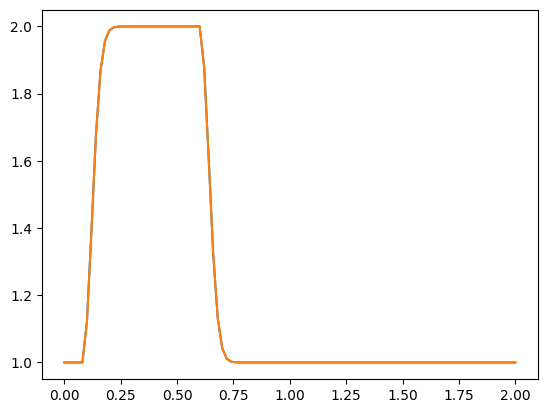

In [ ]:
upwind_c(101,-1)